In [2]:
import pandas as pd
import re
import nltk
import spacy
import seaborn as sns
import matplotlib.pyplot as plt
from nltk import word_tokenize


In [3]:
sample_df = pd.read_excel("./ner.xlsx")
sample_df.head()

,Unnamed: 0,headline,category,short_description,full_news,tags
0,0,U.S. Lawmakers Join Demand For Puerto Rico Gov...,POLITICS,Puerto Ricans staged week-long protests callin...,"['u', 'lawmakers', 'join', 'demand', 'puerto',...","[('puerto', 'GPE'), ('ricans', 'ORG'), ('rosse..."
1,4,Donald Trump Loved To Cite The Nonpartisan Age...,POLITICS,The Congressional Budget Office's projection a...,"['donald', 'trump', 'loved', 'cite', 'nonparti...","[('donald', 'PERSON'), ('trump', 'PERSON'), ('..."
2,5,Transit Cop Investigated After Quizzing Passen...,POLITICS,Exchange on Minneapolis train goes viral.,"['transit', 'cop', 'investigated', 'quizzing',...","[('minneapolis', 'GPE')]"
3,6,Watch The 2016 Democratic National Convention ...,POLITICS,Sen. Elizabeth Warren is the keynote speaker f...,"['watch', 'democratic', 'national', 'conventio...","[('democratic', 'NORP'), ('livesen', 'PERSON')..."
4,7,Judge Says Injunction Against Clean Water Rule...,POLITICS,The EPA maintained after Erickson's initial ru...,"['judge', 'says', 'injunction', 'clean', 'wate...","[('epa', 'ORG'), ('erickson', 'ORG')]"


In [19]:

# wordcloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
all_tags = "".join(sample_df['full_news'])
wordcloud = WordCloud(width=800, height=800, random_state=21, max_font_size=110).generate(all_tags)

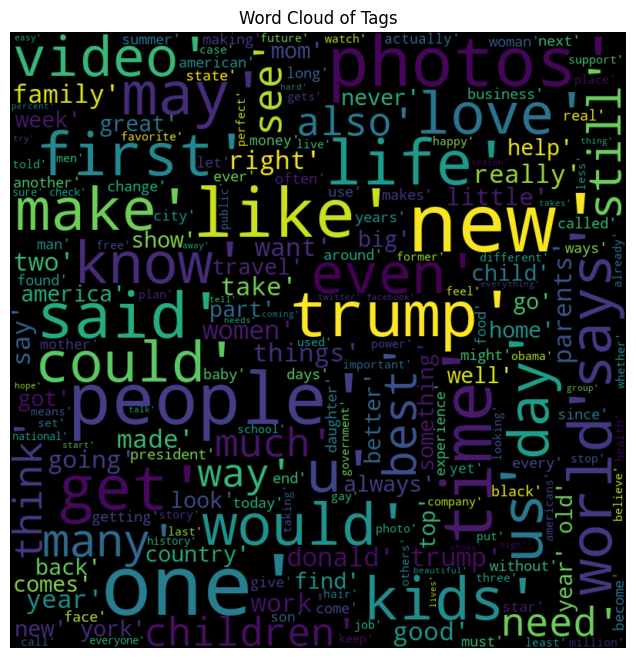

In [20]:
plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Tags')
plt.axis('off')  # Remove axis
plt.show()

In [16]:
doc=  sample_df['tags'][0].replace('',"")
print(doc)

[('puerto', 'GPE'), ('ricans', 'ORG'), ('rossello', 'GPE')]


In [17]:
import pandas as pd

# Extract unique labels
labels = list(set(label for _, label in sample))

# Initialize a dictionary with empty lists for each label
table_dict = {label: [] for label in labels}

# Fill the dictionary with the respective texts
for text, label in data:
    table_dict[label].append(text)

# Create a DataFrame, aligning rows by the longest column
max_length = max(len(table_dict[label]) for label in labels)
for label in labels:
    table_dict[label] += [None] * (max_length - len(table_dict[label]))

df = pd.DataFrame(table_dict)

# Print the DataFrame
print(df)


      ORG       GPE
0  ricans    puerto
1    None  rossello


In [28]:
def create_dataframe(sample):
    # Extract unique labels
    labels = list(set(label for _, label in sample))

    # Initialize a dictionary with empty lists for each label
    table_dict = {label: [] for label in labels}

    # Fill the dictionary with the respective texts
    for text, label in sample:
        table_dict[label].append(text)

    # Create a DataFrame, aligning rows by the longest column
    max_length = max(len(table_dict[label]) for label in labels)
    for label in labels:
        table_dict[label] += [None] * (max_length - len(table_dict[label]))

    return pd.DataFrame(table_dict)

